# Stronger Augmentations Model
**Phase 2: Fine-tuned ResNet-50 Classifier**
**CSC 487 - Winter 2026**  
**Goal:** Fine-tune a pretrained ResNet-50 to classify artwork as AI-generated or human-created.

In [11]:
%%capture
!pip install torchvision

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score

from tqdm.notebook import tqdm
import torch
import torch.nn as nn


import random

In [13]:
DATA_PATH = "/content/Chameleon/Chameleon/test"

## Step 1: Set Up Data Transforms
We resize to 224x224 (what ResNet-50 expects) and normalize using ImageNet stats.  
Training data also gets random flips, rotations, and color jitter for data augmentation.

In [14]:
from PIL import Image
import io

class RandomJPEGCompression:
    def __init__(self, min_quality=40, max_quality=100, p=0.5):
        self.min_quality = min_quality
        self.max_quality = max_quality
        self.p = p

    def __call__(self, img):
        if random.random() > self.p:
            return img

        buffer = io.BytesIO()
        quality = random.randint(self.min_quality, self.max_quality)
        img.save(buffer, format="JPEG", quality=quality)
        buffer.seek(0)
        return Image.open(buffer)

In [15]:
class AddGaussianNoise:
    def __init__(self, mean=0., std=0.02):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn(tensor.size()) * self.std + self.mean

In [16]:
class RandomFrequencyMask:
    def __init__(self, p=0.5, max_radius=0.3):
        self.p = p
        self.max_radius = max_radius

    def __call__(self, tensor):
        if torch.rand(1) > self.p:
            return tensor

        img = tensor.numpy()
        c, h, w = img.shape

        for i in range(c):
            f = np.fft.fft2(img[i])
            fshift = np.fft.fftshift(f)

            cx, cy = w // 2, h // 2
            radius = int(min(cx, cy) * self.max_radius)

            mask = np.ones((h, w))
            y, x = np.ogrid[:h, :w]
            mask_area = (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2
            mask[mask_area] = 0

            fshift = fshift * mask

            f_ishift = np.fft.ifftshift(fshift)
            img[i] = np.real(np.fft.ifft2(f_ishift))

        return torch.tensor(img, dtype=tensor.dtype)

In [17]:
# transform the data for phase 1, and randomly alter images so that model sees variety (augmentation)
train_transform = transforms.Compose([

    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    RandomJPEGCompression(p=0.5),
    transforms.ToTensor(),
    RandomFrequencyMask(p=0.3),

    AddGaussianNoise(0., 0.02),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# transform for validation and test data w/ no augmentation essentially like not using fit
val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

print("transforms defined!")

transforms defined!


## Step 2: Load the Dataset and Split It
We load the full dataset, then split into 70% train / 15% val / 15% test using stratified sampling so both classes stay proportional in each split.

In [18]:
import os
import zipfile
from google.colab import drive


drive.mount('/content/drive')

zip_path = "/content/drive/MyDrive/Chameleon.zip"
extract_path = "/content/Chameleon"

if not os.path.exists(extract_path):
    print("Extracting zip file...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Extraction complete.")
else:
    print("Folder already exists, skipping extraction.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extracting zip file...
Extraction complete.


In [19]:

image_transformer = torchvision.models.VGG16_Weights.IMAGENET1K_V1.transforms()
extracted_data = datasets.ImageFolder(DATA_PATH, transform=image_transformer)

In [29]:
DEBUGGING = False

if DEBUGGING:
  random_seed = 42
  random.seed(random_seed)

  num_images = len(extracted_data)
  random_indices = random.sample(range(num_images), 1000)
  image_data = Subset(extracted_data, random_indices)

  all_labels = [extracted_data.targets[i] for i in random_indices]

else:
  image_data = extracted_data
  all_labels = extracted_data.targets
  print("class names:", image_data.classes)

dataset_len = len(image_data)
all_indices = list(range(dataset_len))


# class names so we know which index is which
print("total images:", len(image_data))
print("label 0 count:", all_labels.count(0))
print("label 1 count:", all_labels.count(1))



class names: ['0_real', '1_fake']
total images: 26033
label 0 count: 14863
label 1 count: 11170


In [30]:
train_val_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

# Labels for train+val for next split
train_val_labels = [all_labels[i] for i in train_val_indices]

# Split train+val into train and val (70/15%)
train_indices, val_indices = train_test_split(
    train_val_indices,
    test_size=0.15/0.85,
    random_state=42,
    stratify=train_val_labels
)

print("train size:", len(train_indices), " - ", (len(train_indices) / len(image_data) * 100), "%")
print("val size:  ", len(val_indices), " - ", (len(val_indices) / len(image_data) * 100), "%")
print("test size: ", len(test_indices), " - ", (len(test_indices) / len(image_data) * 100), "%")

train size: 18223  -  69.99961587216225 %
val size:   3905  -  15.00019206391887 %
test size:  3905  -  15.00019206391887 %


In [31]:
full_dataset_train = datasets.ImageFolder(DATA_PATH, transform=train_transform)

full_dataset_val_test = datasets.ImageFolder(DATA_PATH, transform=val_test_transform)

# subset is like [:] so we can access dataset by index list
train_dataset = Subset(full_dataset_train,   train_indices)
val_dataset   = Subset(full_dataset_val_test, val_indices)
test_dataset  = Subset(full_dataset_val_test, test_indices)


In [32]:
from torchvision.transforms import v2
from torch.utils.data import default_collate

# MIXUP and CUTMIX
NUM_CLASSES = 2
cutmix = v2.CutMix(num_classes=NUM_CLASSES)
mixup = v2.MixUp(num_classes=NUM_CLASSES)
cutmix_or_mixup = v2.RandomChoice([cutmix, mixup])

def collate_fn(batch):
    return cutmix_or_mixup(*default_collate(batch))

# DATALOADING
BATCH_SIZE = 32

train_subset = Subset(image_data, train_indices)
#train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,collate_fn=collate_fn)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True)

# val_loader
val_subset = Subset(image_data, val_indices)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False)

# test_loader
test_subset = Subset(image_data, test_indices)
test_loader = DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=False)


print("train batches:", len(train_loader))
print("val batches:  ", len(val_loader))
print("test batches: ", len(test_loader))

train batches: 570
val batches:   123
test batches:  123


## Step 3: Build the Model
We load ResNet-50 pretrained on ImageNet, then replace the final layer with a new 2-class output layer. Everything else stays frozen at first so we dont destroy the pretrained weights.

In [33]:
# weights=IMAGENET1K_V1 = we want the weights trained on ImageNet
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

# freeze all the layers - we dont want to change the pretrained weights yet
for param in model.parameters():
    param.requires_grad = False

# replace the final fully connected layer with a new one that outputs 2 classes
num_features = model.fc.in_features
print("original fc input features:", num_features)

# replace with a simple linear layer for binary classification
# 2 outputs = AI art (0) or Human art (1)
model.fc = nn.Linear(num_features, 2)

# the new fc layer's parameters are unfrozen by default so only it will train
print("replaced final layer with 2-class output")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print("using device:", device)

original fc input features: 2048
replaced final layer with 2-class output
using device: cuda


## Step 4: Define Loss, Optimizer, and Helper Functions

In [34]:

loss_fn = nn.CrossEntropyLoss()

# filter(lambda p: p.requires_grad ...) gets only the trainable parameters
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)



In [35]:
def get_accuracy(model, loader, device, use_soft_labels=False):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Evaluating", leave=False):
            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            if use_soft_labels:
                labels_hard = labels.argmax(dim=1)
                correct += (preds == labels_hard).sum().item()
            else:
                correct += (preds == labels).sum().item()
            total += labels.size(0)

    return correct / total

## Step 5: Train the Model
We run the training loop for a set number of epochs. Each epoch the model sees the whole training set once.

In [36]:
NUM_EPOCHS = 5

train_acc_history = []
val_acc_history = []
train_loss_history = []

for epoch in range(NUM_EPOCHS):

    model.train()
    total_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}"):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    train_acc = get_accuracy(model, train_loader, device, use_soft_labels=False)
    val_acc = get_accuracy(model, val_loader, device)
    avg_loss = total_loss / len(train_loader)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)
    train_loss_history.append(avg_loss)

    print(f"epoch: {epoch+1:2d}/{NUM_EPOCHS}  loss: {avg_loss:.8f}  train acc: {train_acc:.4f}  val acc: {val_acc:.4f}")

print("\ntraining done!")

Epoch 1/5:   0%|          | 0/570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/123 [00:00<?, ?it/s]

epoch:  1/5  loss: 0.31552631  train acc: 0.9058  val acc: 0.8973


Epoch 2/5:   0%|          | 0/570 [00:00<?, ?it/s]

...

epoch:  4/5  loss: 0.25712743  train acc: 0.9204  val acc: 0.9081


Epoch 5/5:   0%|          | 0/570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/570 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/123 [00:00<?, ?it/s]

epoch:  5/5  loss: 0.24879626  train acc: 0.9228  val acc: 0.9081

training done!


## Step 6: Plot Training Curves

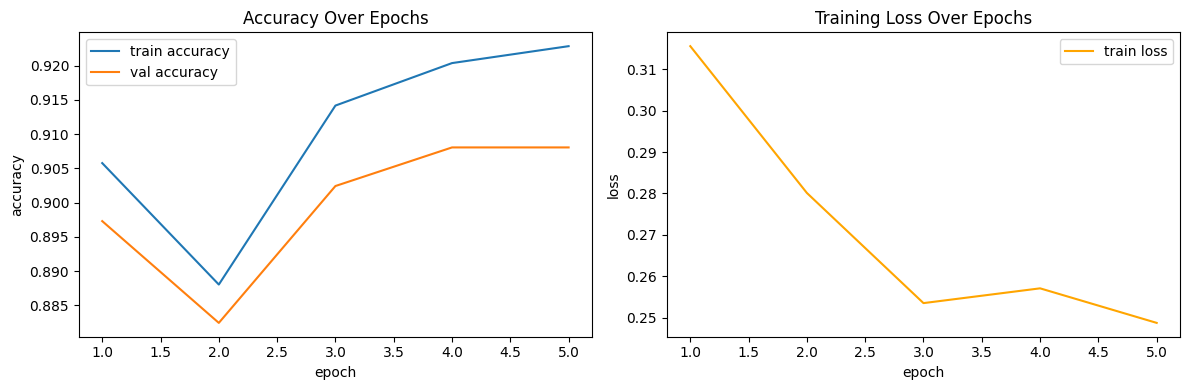

saved training_curves.png


In [37]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

# left plot - accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, train_acc_history, label="train accuracy")
plt.plot(epochs, val_acc_history,   label="val accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy Over Epochs")
plt.legend()

# right plot - loss
plt.subplot(1, 2, 2)
plt.plot(epochs, train_loss_history, label="train loss", color="orange")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Training Loss Over Epochs")
plt.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("saved training_curves.png")

## Step 7: Evaluate on the Test Set
Now we run the model on the held-out test set and compute all our metrics: accuracy, precision, recall, F1, and AUC.

In [38]:
model.eval()

all_true_labels  = []
all_predictions = []
# probabilities for AUC
all_probabilities = []

with torch.no_grad():

    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)

        probabilitiess = torch.softmax(outputs, dim=1)
        predictions = torch.argmax(outputs, dim=1)

        all_true_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predictions.cpu().numpy())

        # save the probability of class 1 (human art) for AUC
        all_probabilities.extend(probabilitiess[:, 1].cpu().numpy())

# compute all the metrics
test_accuracy  = accuracy_score(all_true_labels, all_predictions)
test_precision = precision_score(all_true_labels, all_predictions)
test_recall    = recall_score(all_true_labels, all_predictions)
test_f1        = f1_score(all_true_labels, all_predictions)
test_auc       = roc_auc_score(all_true_labels, all_probabilities)

print("=== TEST SET RESULTS ===")
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1 Score:  {test_f1:.4f}")
print(f"AUC:       {test_auc:.4f}")

=== TEST SET RESULTS ===
Accuracy:  0.9065
Precision: 0.8827
Recall:    0.9021
F1 Score:  0.8923
AUC:       0.9660


## Step 8: Confusion Matrix

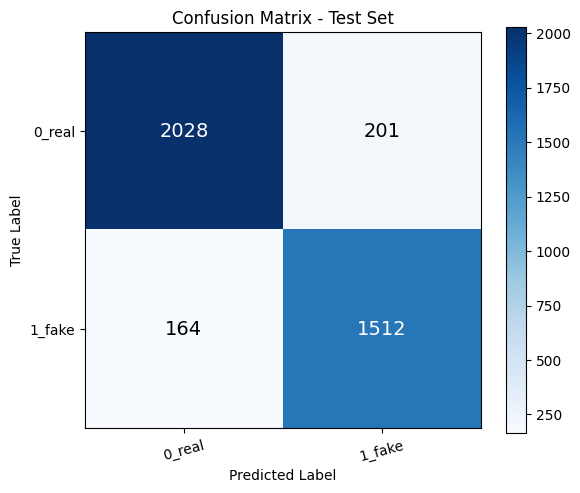

saved confusion_matrix.png


In [39]:
# rows = true labels, columns = predicted labels
cm = confusion_matrix(all_true_labels, all_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

# label the axes with class names
class_names = image_data.classes
plt.xticks([0, 1], class_names, rotation=15)
plt.yticks([0, 1], class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Test Set")

# print the numbers inside each cell
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]),
                 ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black",
                 fontsize=14)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()
print("saved confusion_matrix.png")

## Step 9: Save the Model
Save the trained weights so we can load them later for Phase 2 without retraining.

In [40]:
# save just the model weights (state_dict) - this is the standard way to save in pytorch
pth_name = "jpeg+gaussian+freq.pth"
torch.save(model.state_dict(), pth_name)
print(f"model saved to {pth_name}")

# to load it later you would do:
# model = models.resnet50()
# model.fc = nn.Linear(model.fc.in_features, 2)
# model.load_state_dict(torch.load("phase1_resnet50_weights.pth"))

model saved to jpeg+gaussian+freq.pth
